<a href="https://colab.research.google.com/github/leeet1004835/colab/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

第一步：載入工具與資料

讀取 train.csv 與 test.csv。

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# 載入資料
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"--- 資料載入完成 ---")
print(f"訓練集維度: {train.shape}")
print(f"測試集維度: {test.shape} \n")

--- 資料載入完成 ---
訓練集維度: (4459, 4993)
測試集維度: (49342, 4992) 



第二步：資料清理與特徵過濾

根據主題實作需求，執行變異數篩選與稀疏特徵刪除。

變異數篩選：刪除所有數值都一樣的特徵（變異數為 0），這能有效減少運算量。

稀疏特徵篩選：依照文件需求，刪除「非零數值比例」低於 1% 的特徵

In [4]:
# 1. 刪除變異數為 0 的特徵
const_cols = [c for c in train.columns if train[c].nunique() <= 1]
train = train.drop(const_cols, axis=1)

# 2. 刪除「非零個數」比例低於 1% 的特徵
non_zero_limit = len(train) * 0.01
# 找出符合條件的欄位 (同時確保 ID 和 target 不被誤刪)
keep_cols = [c for c in train.columns if (train[c] != 0).sum() >= non_zero_limit or c in ['ID', 'target']]
train = train[keep_cols]

print(f"--- 資料清理完成 ---")
print(f"清理後剩餘特徵數: {train.shape[1] - 2}")

--- 資料清理完成 ---
清理後剩餘特徵數: 2627


第三步：目標變數 Log 轉換

觀察 target 分佈並進行 Log 轉換，以符合 RMSLE 評估指標要求。

由於客戶交易價值的分布通常極度不均勻（長尾分布），必須先進行 Log 轉換：

公式：target_log = np.log1p(target)

這能讓模型在評估時更穩定，且能直接優化專案要求的 RMSLE 指標。

In [5]:
# 進行 Log 轉換，優化專案要求的 RMSLE 指標
train['target_log'] = np.log1p(train['target'])

# 準備特徵 (X) 與目標 (y)
X_all = train.drop(['ID', 'target', 'target_log'], axis=1)
y_log = train['target_log']

第四步：相關性篩選與模型訓練

保留前 200 個高相關特徵，並建立三種回歸模型。

使用 SelectKBest 配合 f_regression，在四千多個匿名特徵中，挑選出與交易價值相關性最強的前 200 個特徵。

Random Forest (隨機森林)：適合建立基準線。

XGBoost：具備強大的殘差優化能力。

LightGBM：運算速度最快，適合處理大量匿名特徵。

In [6]:
# 1. 使用 SelectKBest 挑選相關性最強的前 200 個特徵
selector = SelectKBest(score_func=f_regression, k=200)
selector.fit(X_all, y_log)
selected_features = X_all.columns[selector.get_support()]

print(f"--- 特徵選取完成 (Top 200) ---")

# 2. 切分資料集 (80% 訓練集, 20% 驗證集)
X_train, X_val, y_train, y_val = train_test_split(X_all[selected_features], y_log, test_size=0.2, random_state=42)

# 3. 模型建立與評估 (三種回歸模型)
# 模型 A:Random Forest (隨機森林)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 模型 B: XGBoost
xgbr = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05)
xgbr.fit(X_train, y_train)

# 模型 C: LightGBM (運算最快且效果佳)
lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05)
lgbm.fit(X_train, y_train)

--- 特徵選取完成 (Top 200) ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26250
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 200
[LightGBM] [Info] Start training from score 14.490748


LGBMRegressor(learning_rate=0.05, n_estimators=500)

第五步：預期產出與驗證

產出特徵重要性排行、散佈圖及符合格式的預測檔案。

Feature Importance：繪製前 50 名最重要的特徵圖表。

Scatter Plot：透過散佈圖觀察預測值與實際值的吻合程度。

Submission：最後記得將預測結果透過 np.expm1() 轉回原始數值，才符合 sample_submission.csv 的格式。

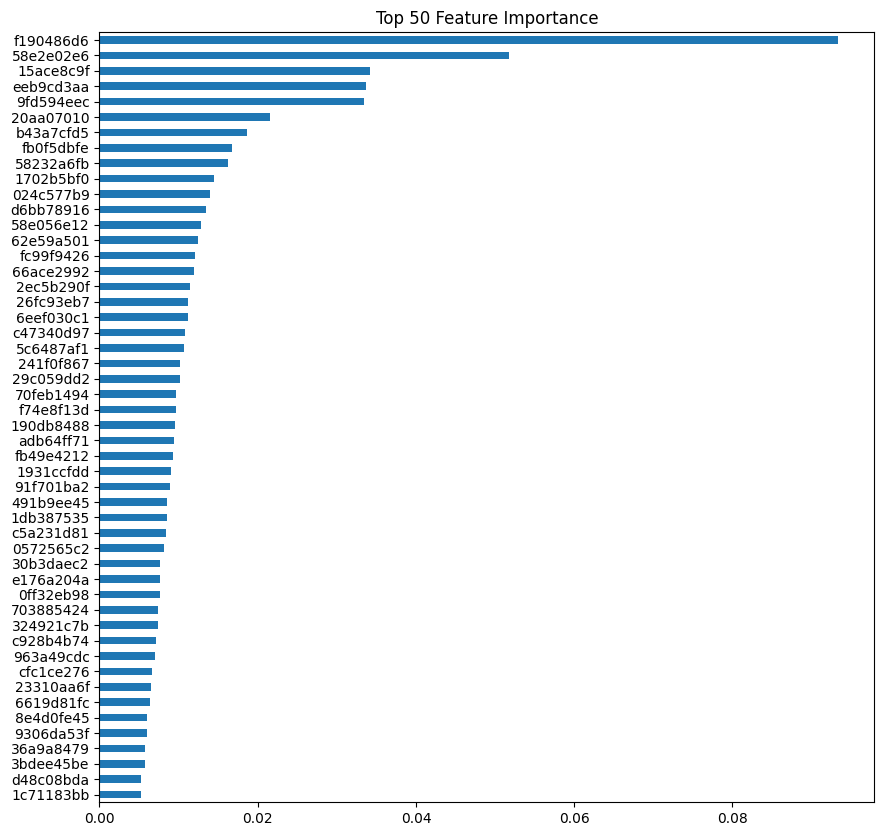

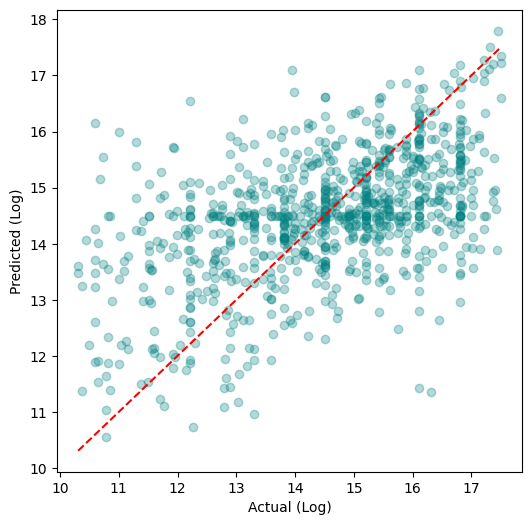

--- 最終評估 ---
模型 RMSLE: 1.4806
平均值 Baseline RMSLE: 1.6963
狀態: 已產出圖表與 submission.csv 檔案。


In [7]:
# 1. 前五十 Feature Importance 排行圖
plt.figure(figsize=(10, 10))
pd.Series(rf.feature_importances_, index=selected_features).sort_values(ascending=False).head(50).plot(kind='barh')
plt.title('Top 50 Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# 2. 比較預測值與真實值的散佈圖 (Scatter Plot)
val_preds = lgbm.predict(X_val)
plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_preds, alpha=0.3, color='teal')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual (Log)')
plt.ylabel('Predicted (Log)')
plt.show()

# 3. 產出符合格式的預測檔案 (submission.csv)
# 將測試集預測結果轉回原始數值 (np.expm1)
test_preds = np.expm1(lgbm.predict(test[selected_features]))
submission = pd.DataFrame({'ID': test['ID'], 'target': test_preds})
submission.to_csv('submission.csv', index=False)

# 4. RMSLE 驗證：檢查是否優於 Baseline (平均值)
model_rmsle = np.sqrt(mean_squared_error(y_val, val_preds))
baseline_rmsle = np.sqrt(mean_squared_error(y_val, np.full(len(y_val), y_train.mean())))

print(f"--- 最終評估 ---")
print(f"模型 RMSLE: {model_rmsle:.4f}")
print(f"平均值 Baseline RMSLE: {baseline_rmsle:.4f}")
print("狀態: 已產出圖表與 submission.csv 檔案。")

心得總結：匿名特徵的重要性量測
在不了解業務邏輯時，我們主要依靠以下方式量測特徵重要性：

統計相關性：利用 f_regression 過濾掉與目標值無線性關係的特徵。

模型貢獻度：利用樹模型（如 Random Forest）在分裂節點時減少的雜質度（Gini Impurity）或增益（Gain）來排序。

稀疏性分析：排除過於稀疏（非零值過少）的特徵，因為它們容易導致模型過擬合（Overfitting）且缺乏泛化能力。